# Challenge 19

Euler's forward vs analytical with a stiff equation

<ipython-input-1-375dc0f24263>:13: RuntimeWarning: overflow encountered in double_scalars
  dy = lambda y, t: -1000*y + 3000 - 2000*np.exp(-t)


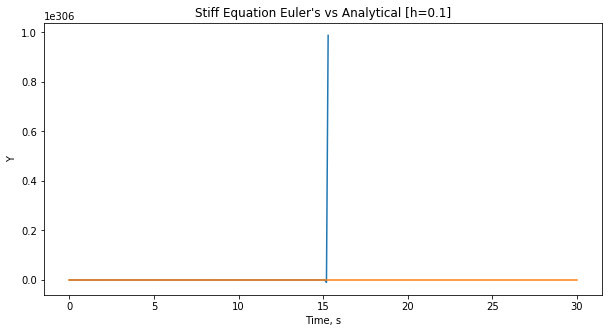

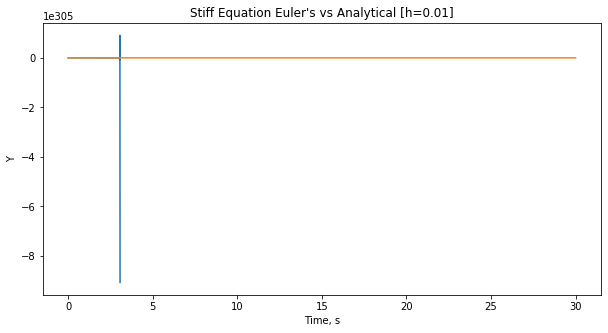

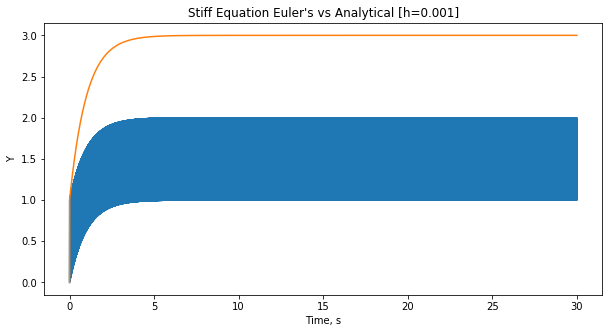

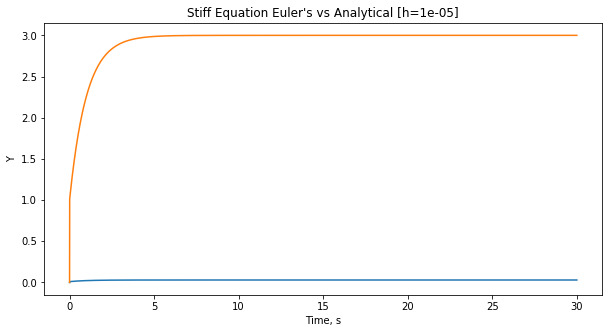

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Toggle to add the extremely small step size h=10^-7 (run time >20 min)
# Run time without: ~20s
extra_h = False

h_values = [0.1, 0.01, 0.001, 0.00001] + ([0.0000001] if extra_h else [])
t_start = 0.0
t_end = 30.0

y0 = 0
dy = lambda y, t: -1000*y + 3000 - 2000*np.exp(-t)
y_func = lambda t: 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

for h in h_values:
    t_values = np.arange(t_start, t_end+h, h)
    y_values = np.zeros_like(t_values)
    
    # Euler's forward
    for i in range(t_values.size - 1):
        y_values[i + 1] = h * dy(y_values[i], t_values[i])
    
    # Analytical solution
    y_real = y_func(t_values)
    
    # Graph result
    plt.figure(figsize=((10,5)))
    plt.plot(t_values, y_values, label="Euler's Forward")
    plt.plot(t_values, y_real, label="Analytical Soln")
    plt.xlabel("Time, s")
    plt.ylabel("Y")
    plt.title(f"Stiff Equation Euler's vs Analytical [h={h}]")
    plt.show()